# TREC CAsT 2019 Dataset Exploration

This notebook provides a thorough analysis of the TREC Conversational Assistance Track (CAsT) 2019 dataset, covering the passage collection, ID mappings, Snowflake embeddings, topics, and relevance judgments.

**Dataset location:** `/home/Datasets/conversational/CAST2019/`

**Virtual environment:** `/home/Datasets/mein_env/`

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pyarrow.parquet as pq

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (10, 5)

BASE = '/home/toploc1/Datasets/conversational/CAST2019'
COLLECTION_PATH   = os.path.join(BASE, 'CAST2019collection.tsv')
MAPPING_PATH      = os.path.join(BASE, 'CAST2019_ID_Mapping.tsv')
EMBEDDINGS_DIR    = os.path.join(BASE, 'snowflake_embeddings')
TOPICS_PATH       = os.path.join(BASE, 'topics', 'topics.tsv')
QRELS_PATH        = os.path.join(BASE, 'topics', 'qrels.qrel')

SAMPLE_ROWS = 100_000  # rows to sample when full scan is too slow
CHUNK_SIZE  = 500_000

print('Libraries loaded.')
print(f'pandas {pd.__version__}  |  numpy {np.__version__}  |  matplotlib {matplotlib.__version__}')

Libraries loaded.
pandas 2.0.3  |  numpy 1.24.4  |  matplotlib 3.7.5


---
## Section 1 — Collection Analysis

**File:** `CAST2019collection.tsv` — tab-separated, columns `id` and `text`.  
The collection is ~38.6 M passages, so we use **chunked reading** for counts/aggregates that need the full dataset and a **100 k sample** for word-count statistics that are too slow to compute on the whole file.

Key things to look for:
- Are MARCO (MS MARCO) and CAR (TREC CAR) passages roughly in the proportions expected?
- Is the word-count distribution roughly right for short retrieved passages (typically 50–200 words)?

In [2]:
# ── 1a. Total passages and MARCO / CAR split via chunked scan ──────────────
total_passages = 0
marco_count    = 0
car_count      = 0

try:
    reader = pd.read_csv(
        COLLECTION_PATH,
        sep='\t',
        names=['id', 'text'],
        header=0,
        chunksize=CHUNK_SIZE,
        dtype=str,
        on_bad_lines='skip'
    )
    for chunk in reader:
        total_passages += len(chunk)
        marco_count    += chunk['id'].str.startswith('MARCO_').sum()
        car_count      += chunk['id'].str.startswith('CAR_').sum()
except Exception as e:
    print(f'ERROR during chunked scan: {e}')

other_count = total_passages - marco_count - car_count
print(f'Total passages : {total_passages:>12,}')
print(f'  MARCO_       : {marco_count:>12,}  ({100*marco_count/total_passages:.2f}%)')
print(f'  CAR_         : {car_count:>12,}  ({100*car_count/total_passages:.2f}%)')
if other_count:
    print(f'  other        : {other_count:>12,}')

Total passages :   38,636,446
  MARCO_       :    8,841,749  (22.88%)
  CAR_         :   29,794,697  (77.12%)


[NOTE] Sampling first 100,000 rows for word-count statistics.
Word count (mean ± std): 53.3 ± 20.5
Min / Max word count   : 2 / 267
Median word count      : 49


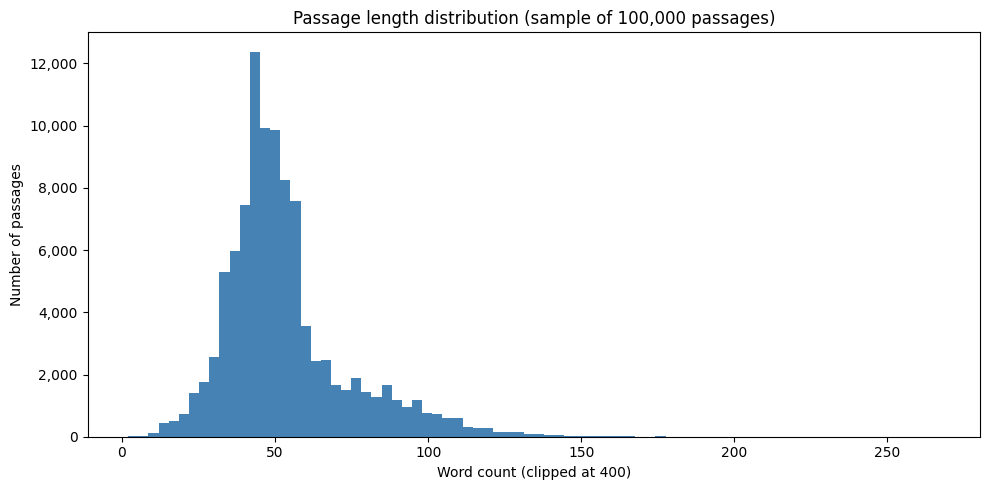

In [3]:
# ── 1b. Word-count stats and distribution — first SAMPLE_ROWS rows ─────────
print(f'[NOTE] Sampling first {SAMPLE_ROWS:,} rows for word-count statistics.')

try:
    sample_df = pd.read_csv(
        COLLECTION_PATH,
        sep='\t',
        names=['id', 'text'],
        header=0,
        nrows=SAMPLE_ROWS,
        dtype=str,
        on_bad_lines='skip'
    )
    sample_df['wc'] = sample_df['text'].fillna('').str.split().str.len()

    mean_wc = sample_df['wc'].mean()
    std_wc  = sample_df['wc'].std()
    print(f'Word count (mean ± std): {mean_wc:.1f} ± {std_wc:.1f}')
    print(f'Min / Max word count   : {sample_df["wc"].min()} / {sample_df["wc"].max()}')
    print(f'Median word count      : {sample_df["wc"].median():.0f}')

    # Histogram
    fig, ax = plt.subplots()
    ax.hist(sample_df['wc'].clip(upper=400), bins=80, color='steelblue', edgecolor='none')
    ax.set_xlabel('Word count (clipped at 400)')
    ax.set_ylabel('Number of passages')
    ax.set_title(f'Passage length distribution (sample of {SAMPLE_ROWS:,} passages)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f'ERROR: {e}')

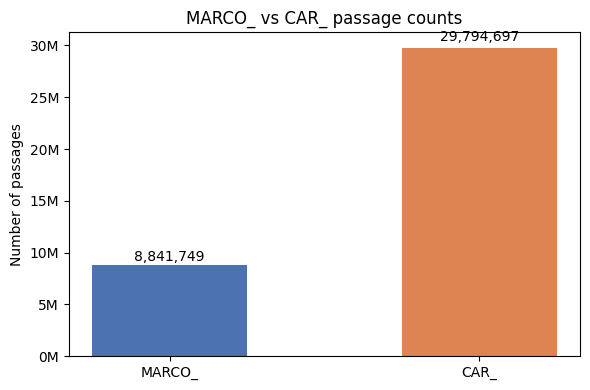

In [4]:
# ── 1c. MARCO / CAR bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
labels  = ['MARCO_', 'CAR_']
counts  = [marco_count, car_count]
colors  = ['#4C72B0', '#DD8452']
bars    = ax.bar(labels, counts, color=colors, width=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'{cnt:,}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of passages')
ax.set_title('MARCO_ vs CAR_ passage counts')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e6):.0f}M'))
plt.tight_layout()
plt.show()

In [5]:
# ── 1d. Shortest and longest 3 passages (from sample) ─────────────────────
print('=== 3 SHORTEST PASSAGES (from sample) ===')
for _, row in sample_df.nsmallest(3, 'wc').iterrows():
    print(f'  id={row["id"]}  wc={row["wc"]}')
    print(f'  text: {str(row["text"])[:200]}')
    print()

print('=== 3 LONGEST PASSAGES (from sample) ===')
for _, row in sample_df.nlargest(3, 'wc').iterrows():
    print(f'  id={row["id"]}  wc={row["wc"]}')
    print(f'  text (first 200 chars): {str(row["text"])[:200]}...')
    print()

=== 3 SHORTEST PASSAGES (from sample) ===
  id=MARCO_33222  wc=2
  text: BOOKING_FEATURES IB_STREAMLINED_SELECTED_ROOMIB_POST_BOOKING_LOGIN_USIB_NEW_REG_FLOW_INTERRUPTERIB_SHOW_EMAIL_FOR_INSECURE_LOGINRCMS_INLINE_ROOM_GRID_MAX_OCCIB_POST_BOOKING_LOGINIB_IRG_PERFORMANCE_MET

  id=MARCO_2601  wc=3
  text: Retrieved from httpwwwlawnotesinwindexphptitleModes_of_acquisition_of_propertyoldid986

  id=MARCO_18512  wc=3
  text: Retrieved from httpsballotpediaorgwikiindexphptitleCategory100_largest_United_States_cities_by_populationoldid5834515

=== 3 LONGEST PASSAGES (from sample) ===
  id=MARCO_24552  wc=267
  text (first 200 chars): High blood cholesterol signals a higher risk of heart attack and stroke Thatas why itas important to have your cholesterol levels checked regularly and discuss them with your doctor A alipoprotein pro...

  id=MARCO_37599  wc=219
  text (first 200 chars): KJV Dictionary Definition devour devour DEVOUR vt L to eat 1 To eat up to eat with greediness to eat ravenous

---
## Section 2 — ID Mapping Analysis

**File:** `CAST2019_ID_Mapping.tsv` — tab-separated, header `index` / `id`.  
The mapping translates 0-based integer indices to passage IDs, providing a dense lookup table for the embedding arrays.

Key checks:
- Index should run from 0 to N−1 with no gaps (contiguous).
- Every ID in the mapping should appear in the collection, and every collection ID should appear in the mapping.

In [6]:
# ── 2a. Load the mapping ──────────────────────────────────────────────────
try:
    mapping_df = pd.read_csv(MAPPING_PATH, sep='\t', dtype={'index': int, 'id': str})
    print(f'Total mapping entries: {len(mapping_df):,}')
    print(f'Columns: {list(mapping_df.columns)}')
    print(f'Index range: {mapping_df["index"].min()} – {mapping_df["index"].max()}')
except Exception as e:
    print(f'ERROR: {e}')
    mapping_df = pd.DataFrame()

Total mapping entries: 38,636,446
Columns: ['index', 'id']
Index range: 0 – 38636445


In [9]:
# ── 2d. MARCO / CAR split in mapping + first / last 5 entries ────────────
if len(mapping_df):
    m_map = mapping_df['id'].str.startswith('MARCO_').sum()
    c_map = mapping_df['id'].str.startswith('CAR_').sum()
    n_map = len(mapping_df)
    print(f'MARCO_ in mapping: {m_map:,}  ({100*m_map/n_map:.2f}%)')
    print(f'CAR_   in mapping: {c_map:,}  ({100*c_map/n_map:.2f}%)')

    print('\n=== First 5 entries ===')
    print(mapping_df.head())
    print('\n=== Last 5 entries ===')
    print(mapping_df.tail())

MARCO_ in mapping: 8,841,749  (22.88%)
CAR_   in mapping: 29,794,697  (77.12%)

=== First 5 entries ===
   index       id
0      0  MARCO_0
1      1  MARCO_1
2      2  MARCO_2
3      3  MARCO_3
4      4  MARCO_4

=== Last 5 entries ===
             index                                            id
38636441  38636441  CAR_ffffff980cb04ef816f96ba20abe06bbbac92d95
38636442  38636442  CAR_ffffffb9eec6224bef5da06e829eef59a37748c6
38636443  38636443  CAR_482c9df113959986eaf548eba5c320082fe39232
38636444  38636444  CAR_6f535580208d708a44bb789101a5f39d9b126fa7
38636445  38636445  CAR_eedb7f8d828a617c9b83d5822a093b62a16b9197


---
## Section 3 — Snowflake Embeddings Analysis

**Directory:** `snowflake_embeddings/` — Parquet files split across two ranks (`rank0`, `rank1`).  
Each file has columns `id` (passage ID string) and `embedding` (dense float vector, expected dim = 1024).

Key checks:
- Total embeddings should match total passages in the collection.
- All IDs in the parquet files should exist in the ID mapping.
- No duplicate IDs across files.

In [10]:
# ── 3a. File inventory ────────────────────────────────────────────────────
rank0_files = sorted(glob.glob(os.path.join(EMBEDDINGS_DIR, '*.rank0.*.parquet')))
rank1_files = sorted(glob.glob(os.path.join(EMBEDDINGS_DIR, '*.rank1.*.parquet')))
all_parquet  = rank0_files + rank1_files

print(f'Parquet files — rank0 : {len(rank0_files)}')
print(f'Parquet files — rank1 : {len(rank1_files)}')
print(f'Total parquet files   : {len(all_parquet)}')
if all_parquet:
    print(f'Example file          : {os.path.basename(all_parquet[0])}')

Parquet files — rank0 : 101
Parquet files — rank1 : 93
Total parquet files   : 194
Example file          : cast2019_snowflake_v2.rank0.part00000.parquet


In [11]:
# ── 3b. Scan all parquet files for embedding count, dim, and IDs ──────────
rows_per_file   = []
emb_dim         = None
total_embeddings = 0
all_emb_ids     = []
dim_mismatch    = []

for fpath in all_parquet:
    try:
        pf     = pq.read_table(fpath, columns=['id', 'embedding'])
        df_pf  = pf.to_pandas()
        n      = len(df_pf)
        rows_per_file.append(n)
        total_embeddings += n
        all_emb_ids.extend(df_pf['id'].tolist())

        # Check embedding dimensionality from first non-null vector
        if emb_dim is None and len(df_pf):
            first_emb = df_pf['embedding'].iloc[0]
            if hasattr(first_emb, '__len__'):
                emb_dim = len(first_emb)
    except Exception as e:
        print(f'ERROR reading {os.path.basename(fpath)}: {e}')

rows_arr = np.array(rows_per_file)
print(f'Total embeddings    : {total_embeddings:,}')
print(f'Embeddings per file : mean={rows_arr.mean():.1f}  std={rows_arr.std():.1f}  min={rows_arr.min()}  max={rows_arr.max()}')
print(f'Embedding dimension : {emb_dim}')

dim_status = 'PASS' if emb_dim == 1024 else 'FAIL'
print(f'[{dim_status}] Expected dimension 1024')

Total embeddings    : 38,636,446
Embeddings per file : mean=199156.9  std=11064.2  min=45725  max=200000
Embedding dimension : 1024
[PASS] Expected dimension 1024


In [12]:
# ── 3c. Verify total embeddings matches collection count ──────────────────
count_status = 'PASS' if total_embeddings == total_passages else 'FAIL'
print(f'Collection passages : {total_passages:,}')
print(f'Total embeddings    : {total_embeddings:,}')
diff = total_embeddings - total_passages
print(f'Difference          : {diff:+,}')
print(f'[{count_status}] Embedding count matches collection count')

Collection passages : 38,636,446
Total embeddings    : 38,636,446
Difference          : +0
[PASS] Embedding count matches collection count


In [13]:
# ── 3d. Duplicate ID check across all parquet files ───────────────────────
print(f'Total IDs collected from parquet files: {len(all_emb_ids):,}')
unique_emb_ids = set(all_emb_ids)
n_dupes        = len(all_emb_ids) - len(unique_emb_ids)
dup_status     = 'PASS' if n_dupes == 0 else 'FAIL'
print(f'Unique IDs: {len(unique_emb_ids):,}')
print(f'Duplicate IDs: {n_dupes:,}')
print(f'[{dup_status}] No duplicate IDs across parquet files')

Total IDs collected from parquet files: 38,636,446
Unique IDs: 38,636,443
Duplicate IDs: 3
[FAIL] No duplicate IDs across parquet files


In [14]:
# ── 3e. Verify parquet IDs align with mapping — sample 10k ───────────────
SAMPLE_EMB = 10_000
print(f'[NOTE] Sampling {SAMPLE_EMB:,} embedding IDs for alignment check.')

sample_emb_ids = set(all_emb_ids[:SAMPLE_EMB])

if len(mapping_df):
    mapping_id_set = set(mapping_df['id'])
    in_mapping     = sample_emb_ids & mapping_id_set
    not_in_mapping = sample_emb_ids - mapping_id_set
    align_status   = 'PASS' if len(not_in_mapping) == 0 else 'FAIL'
    print(f'Sampled embedding IDs : {len(sample_emb_ids):,}')
    print(f'Found in mapping      : {len(in_mapping):,}')
    print(f'NOT in mapping        : {len(not_in_mapping):,}')
    print(f'[{align_status}] Sampled parquet IDs align with mapping')
    if not_in_mapping:
        print(f'Examples missing: {list(not_in_mapping)[:5]}')
else:
    print('Mapping not loaded — skipping alignment check.')

[NOTE] Sampling 10,000 embedding IDs for alignment check.
Sampled embedding IDs : 10,000
Found in mapping      : 10,000
NOT in mapping        : 0
[PASS] Sampled parquet IDs align with mapping


---
## Section 4 — Topics Analysis

**File:** `topics/topics.tsv` — comma-separated, no header, columns `query_id` and `query`.  
Query IDs follow the pattern `<conv_id>_<turn>`, e.g. `31_1` is turn 1 of conversation 31.

Key things to look for:
- How many conversations and turns in total?
- Are conversations evenly long, or do some have many more turns?
- Are individual queries short (like real search queries) or longer and more descriptive?

In [16]:
# ── 4a. Load topics ───────────────────────────────────────────────────────
try:
    topics_df = pd.read_csv(
        TOPICS_PATH,
        sep=',',
        header=None,
        names=['query_id', 'query'],
        dtype=str
    )
    topics_df['conv_id']   = topics_df['query_id'].str.split('_').str[0]
    topics_df['turn']      = topics_df['query_id'].str.split('_').str[1].astype(int)
    topics_df['query_wc']  = topics_df['query'].fillna('').str.split().str.len()

    print(f'Total queries          : {len(topics_df):,}')
    print(f'Unique conversations   : {topics_df["conv_id"].nunique():,}')
    print(f'Query word count       : mean={topics_df["query_wc"].mean():.2f}  std={topics_df["query_wc"].std():.2f}')
    print(f'Query word count range : {topics_df["query_wc"].min()} – {topics_df["query_wc"].max()}')
except Exception as e:
    print(f'ERROR: {e}')
    topics_df = pd.DataFrame()

Total queries          : 479
Unique conversations   : 50
Query word count       : mean=7.54  std=2.40
Query word count range : 3 – 19


Turns per conversation:
  mean=9.58  std=1.20
  min=7  max=12


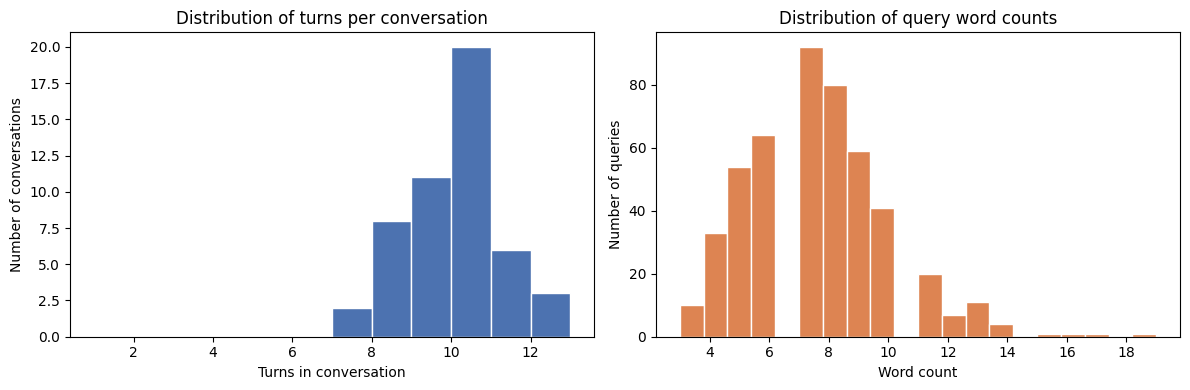

In [17]:
# ── 4b. Turns per conversation ────────────────────────────────────────────
if len(topics_df):
    turns_per_conv = topics_df.groupby('conv_id')['turn'].count()
    print(f'Turns per conversation:')
    print(f'  mean={turns_per_conv.mean():.2f}  std={turns_per_conv.std():.2f}')
    print(f'  min={turns_per_conv.min()}  max={turns_per_conv.max()}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Turns-per-conversation histogram
    axes[0].hist(turns_per_conv, bins=range(1, turns_per_conv.max()+2), color='#4C72B0', edgecolor='white')
    axes[0].set_xlabel('Turns in conversation')
    axes[0].set_ylabel('Number of conversations')
    axes[0].set_title('Distribution of turns per conversation')

    # Query word count histogram
    axes[1].hist(topics_df['query_wc'], bins=20, color='#DD8452', edgecolor='white')
    axes[1].set_xlabel('Word count')
    axes[1].set_ylabel('Number of queries')
    axes[1].set_title('Distribution of query word counts')

    plt.tight_layout()
    plt.show()

In [18]:
# ── 4c. Example conversation ──────────────────────────────────────────────
if len(topics_df):
    # Pick the conversation with the most turns for a rich example
    example_conv_id = turns_per_conv.idxmax()
    conv_df = topics_df[topics_df['conv_id'] == example_conv_id].sort_values('turn')
    print(f'=== Conversation {example_conv_id} ({len(conv_df)} turns) ===')
    for _, row in conv_df.iterrows():
        print(f'  Turn {row["turn"]:>2}  [{row["query_id"]}]: {row["query"]}')

=== Conversation 37 (12 turns) ===
  Turn  1  [37_1]: What was the Stanford Experiment?
  Turn  2  [37_2]: What did the Stanford Experiment show?
  Turn  3  [37_3]: Tell me about the author of the Stanford Experiment.
  Turn  4  [37_4]: Was the Stanford Experiment ethical?
  Turn  5  [37_5]: What are other similar experiments to the Stanford Experiment?
  Turn  6  [37_6]: What happened in the Milgram experiment?
  Turn  7  [37_7]: Why was the Milgram experiment important?
  Turn  8  [37_8]: What were the similarities and differences between the Stanford Experiment and the Milgram experiment?
  Turn  9  [37_9]: What about the BBC experiment?
  Turn 10  [37_10]: What are the key findings of the BBC experiment?
  Turn 11  [37_11]: How did the results of the BBC experiment differ from the Milgram experiment?
  Turn 12  [37_12]: Why was the BBC experiment ended?


---
## Section 5 — Relevance Judgments Analysis

**File:** `topics/qrels.qrel` — comma-separated, no header, columns `query_id`, `iteration`, `passage_id`, `relevance`.  
Relevance scores: 0 = not relevant, 1 = somewhat relevant, 2 = relevant, 3 = highly relevant.

Key things to look for:
- The distribution of relevance scores tells you how hard the task is and how the assessors judged passages.
- Are all judged passage IDs present in the ID mapping (sanity check that the judgments reference known passages)?

In [19]:
# ── 5a. Load qrels ────────────────────────────────────────────────────────
try:
    qrels_df = pd.read_csv(
        QRELS_PATH,
        sep=',',
        header=None,
        names=['query_id', 'iteration', 'passage_id', 'relevance'],
        dtype={'query_id': str, 'iteration': str, 'passage_id': str, 'relevance': int}
    )
    print(f'Total judgments : {len(qrels_df):,}')
    print(f'Unique queries  : {qrels_df["query_id"].nunique():,}')
    print(f'Unique passages : {qrels_df["passage_id"].nunique():,}')
except Exception as e:
    print(f'ERROR: {e}')
    qrels_df = pd.DataFrame()

Total judgments : 29,350
Unique queries  : 173
Unique passages : 21,726


In [20]:
# ── 5b. Judged passages per query ─────────────────────────────────────────
if len(qrels_df):
    judged_per_query = qrels_df.groupby('query_id')['passage_id'].count()
    print('Judged passages per query:')
    print(f'  mean={judged_per_query.mean():.2f}  std={judged_per_query.std():.2f}')
    print(f'  min={judged_per_query.min()}  max={judged_per_query.max()}')

Judged passages per query:
  mean=169.65  std=36.69
  min=84  max=266


Average relevance score: 0.6148

Score           Count   Percentage
----------------------------------
0              21,230       72.33%
1               2,889        9.84%
2               2,157        7.35%
3               1,456        4.96%
4               1,618        5.51%


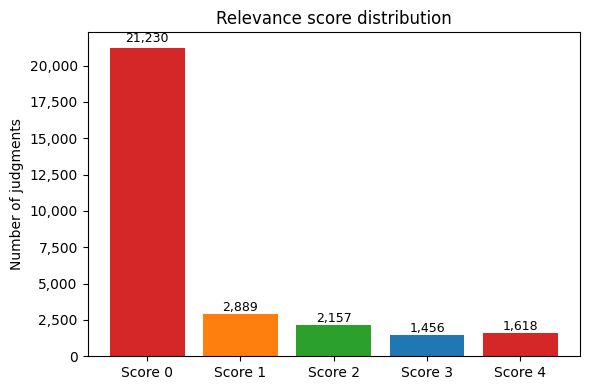

In [21]:
# ── 5c. Relevance score distribution ─────────────────────────────────────
if len(qrels_df):
    rel_counts = qrels_df['relevance'].value_counts().sort_index()
    total_j    = len(qrels_df)
    avg_rel    = qrels_df['relevance'].mean()

    print(f'Average relevance score: {avg_rel:.4f}')
    print()
    print(f'{"Score":<10} {"Count":>10} {"Percentage":>12}')
    print('-' * 34)
    for score, cnt in rel_counts.items():
        print(f'{score:<10} {cnt:>10,} {100*cnt/total_j:>11.2f}%')

    fig, ax = plt.subplots(figsize=(6, 4))
    score_labels = [f'Score {s}' for s in rel_counts.index]
    bars = ax.bar(score_labels, rel_counts.values, color=['#d62728','#ff7f0e','#2ca02c','#1f77b4'][:len(rel_counts)])
    for bar, cnt in zip(bars, rel_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{cnt:,}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Number of judgments')
    ax.set_title('Relevance score distribution')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

In [23]:
# ── 5e. MARCO_ vs CAR_ in qrels ──────────────────────────────────────────
if len(qrels_df):
    q_marco = qrels_df['passage_id'].str.startswith('MARCO_').sum()
    q_car   = qrels_df['passage_id'].str.startswith('CAR_').sum()
    q_total = len(qrels_df)
    print(f'MARCO_ passages in qrels: {q_marco:,}  ({100*q_marco/q_total:.2f}%)')
    print(f'CAR_   passages in qrels: {q_car:,}  ({100*q_car/q_total:.2f}%)')

MARCO_ passages in qrels: 15,337  (52.26%)
CAR_   passages in qrels: 14,013  (47.74%)


---
## Section 6 — Cross Validation

This section ties everything together: verifying that the query IDs in `topics.tsv` and `qrels.qrel` are consistent, and presenting a final summary table of all key counts.

A query present in topics but not in qrels means it was never judged — which would be problematic for evaluation. A query in qrels but not in topics is also an anomaly.

In [24]:
# ── 6a. Topics ↔ qrels query ID cross-check ───────────────────────────────
if len(topics_df) and len(qrels_df):
    topic_qids = set(topics_df['query_id'])
    qrel_qids  = set(qrels_df['query_id'])

    in_topics_only = topic_qids - qrel_qids
    in_qrels_only  = qrel_qids  - topic_qids
    in_both        = topic_qids & qrel_qids

    print(f'Query IDs in topics            : {len(topic_qids):,}')
    print(f'Query IDs in qrels             : {len(qrel_qids):,}')
    print(f'In both topics and qrels       : {len(in_both):,}')
    print()

    t_only_status = 'PASS' if len(in_topics_only) == 0 else 'WARN'
    q_only_status = 'PASS' if len(in_qrels_only) == 0 else 'WARN'
    print(f'[{t_only_status}] In topics but NOT in qrels ({len(in_topics_only):,}): {sorted(in_topics_only) if in_topics_only else "none"}')
    print(f'[{q_only_status}] In qrels  but NOT in topics ({len(in_qrels_only):,}): {sorted(in_qrels_only) if in_qrels_only else "none"}')
else:
    print('Topics or qrels not loaded — skipping cross-check.')

Query IDs in topics            : 479
Query IDs in qrels             : 173
In both topics and qrels       : 173

[WARN] In topics but NOT in qrels (306): ['33_10', '33_9', '34_9', '35_1', '35_2', '35_3', '35_4', '35_5', '35_6', '35_7', '35_8', '35_9', '36_1', '36_10', '36_11', '36_2', '36_3', '36_4', '36_5', '36_6', '36_7', '36_8', '36_9', '37_10', '37_11', '37_12', '37_9', '38_1', '38_2', '38_3', '38_4', '38_5', '38_6', '38_7', '38_8', '39_1', '39_2', '39_3', '39_4', '39_5', '39_6', '39_7', '39_8', '39_9', '40_10', '40_9', '41_1', '41_2', '41_3', '41_4', '41_5', '41_6', '41_7', '41_8', '41_9', '42_1', '42_2', '42_3', '42_4', '42_5', '42_6', '42_7', '42_8', '43_1', '43_2', '43_3', '43_4', '43_5', '43_6', '43_7', '43_8', '44_1', '44_2', '44_3', '44_4', '44_5', '44_6', '44_7', '44_8', '45_1', '45_2', '45_3', '45_4', '45_5', '45_6', '45_7', '45_8', '46_1', '46_10', '46_2', '46_3', '46_4', '46_5', '46_6', '46_7', '46_8', '46_9', '47_1', '47_2', '47_3', '47_4', '47_5', '47_6', '47_7', '48_1'

In [25]:
# ── 6b. Final summary table ───────────────────────────────────────────────
summary_rows = []

summary_rows.append(('Collection — total passages',      f'{total_passages:,}'))
summary_rows.append(('Collection — MARCO_ passages',     f'{marco_count:,}  ({100*marco_count/max(total_passages,1):.1f}%)'))
summary_rows.append(('Collection — CAR_ passages',       f'{car_count:,}  ({100*car_count/max(total_passages,1):.1f}%)'))
if len(sample_df):
    summary_rows.append(('Collection — avg word count (sample)', f'{sample_df["wc"].mean():.1f} ± {sample_df["wc"].std():.1f}'))

if len(mapping_df):
    summary_rows.append(('ID Mapping — total entries',   f'{len(mapping_df):,}'))
    summary_rows.append(('ID Mapping — contiguous',      'Yes' if is_contiguous else 'No'))

summary_rows.append(('Embeddings — total parquet files', f'{len(all_parquet)}  (rank0={len(rank0_files)}, rank1={len(rank1_files)})'))
summary_rows.append(('Embeddings — total embeddings',    f'{total_embeddings:,}'))
summary_rows.append(('Embeddings — dimension',           f'{emb_dim}'))
summary_rows.append(('Embeddings — duplicate IDs',       f'{n_dupes:,}'))

if len(topics_df):
    summary_rows.append(('Topics — total queries',          f'{len(topics_df):,}'))
    summary_rows.append(('Topics — unique conversations',   f'{topics_df["conv_id"].nunique():,}'))
    summary_rows.append(('Topics — avg turns/conversation', f'{turns_per_conv.mean():.2f} ± {turns_per_conv.std():.2f}'))
    summary_rows.append(('Topics — avg query word count',   f'{topics_df["query_wc"].mean():.2f} ± {topics_df["query_wc"].std():.2f}'))

if len(qrels_df):
    summary_rows.append(('Qrels — total judgments',         f'{len(qrels_df):,}'))
    summary_rows.append(('Qrels — unique queries',          f'{qrels_df["query_id"].nunique():,}'))
    summary_rows.append(('Qrels — avg passages/query',      f'{judged_per_query.mean():.2f} ± {judged_per_query.std():.2f}'))
    summary_rows.append(('Qrels — avg relevance score',     f'{qrels_df["relevance"].mean():.4f}'))

summary_table = pd.DataFrame(summary_rows, columns=['Metric', 'Value'])
print(summary_table.to_string(index=False))

                              Metric                      Value
         Collection — total passages                 38,636,446
        Collection — MARCO_ passages         8,841,749  (22.9%)
          Collection — CAR_ passages        29,794,697  (77.1%)
Collection — avg word count (sample)                53.3 ± 20.5
          ID Mapping — total entries                 38,636,446
             ID Mapping — contiguous                        Yes
    Embeddings — total parquet files 194  (rank0=101, rank1=93)
       Embeddings — total embeddings                 38,636,446
              Embeddings — dimension                       1024
          Embeddings — duplicate IDs                          3
              Topics — total queries                        479
       Topics — unique conversations                         50
     Topics — avg turns/conversation                9.58 ± 1.20
       Topics — avg query word count                7.54 ± 2.40
             Qrels — total judgments    

In [26]:
# ── 6c. Render the summary as a styled table ──────────────────────────────
try:
    from IPython.display import display
    display(summary_table.style
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left'), ('background-color', '#4C72B0'), ('color', 'white')]}])
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))
except Exception:
    pass  # Already printed above

print('\nExploration complete.')

Metric,Value
Collection — total passages,"38,636,446"
Collection — MARCO_ passages,"8,841,749 (22.9%)"
Collection — CAR_ passages,"29,794,697 (77.1%)"
Collection — avg word count (sample),53.3 ± 20.5
ID Mapping — total entries,"38,636,446"
ID Mapping — contiguous,Yes
Embeddings — total parquet files,"194 (rank0=101, rank1=93)"
Embeddings — total embeddings,"38,636,446"
Embeddings — dimension,1024
Embeddings — duplicate IDs,3



Exploration complete.
